In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

In [13]:
# Load data and split into feature and target variables
col_names = [
    "id","diagnosis","radius_mean","texture_mean","perimeter_mean","area_mean","smoothness_mean",
    "compactness_mean","concavity_mean","concave_points_mean","symmetry_mean","fractal_dimension_mean","radius_se",
    "texture_se","perimeter_se","area_se","smoothness_se","compactness_se","concavity_se","concave_points_se",
    "symmetry_se","fractal_dimension_se","radius_worst","texture_worst","perimeter_worst","area_worst",
    "smoothness_worst","compactness_worst","concavity_worst","concave_points_worst","symmetry_worst","fractal_dimension_worst"
]
df = pd.read_csv("wdbc.data", header=None, names=col_names)
X = df.drop(["id", "diagnosis"], axis=1) #feature
y = df["diagnosis"] #target

In [16]:
# View first 5 rows of the data
df.head(5)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [19]:
# How frequently does the positive target occur?
print(f'Positive target occurs {y.value_counts(normalize=True)["M"]:.2%}')

Positive target occurs 37.26%


In [21]:
# Generate summary statistics for the data
df.describe(include="all")

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
unique,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,357,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,3.037183e+07,NaN,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,NaN,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,NaN,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,NaN,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,NaN,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,NaN,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080


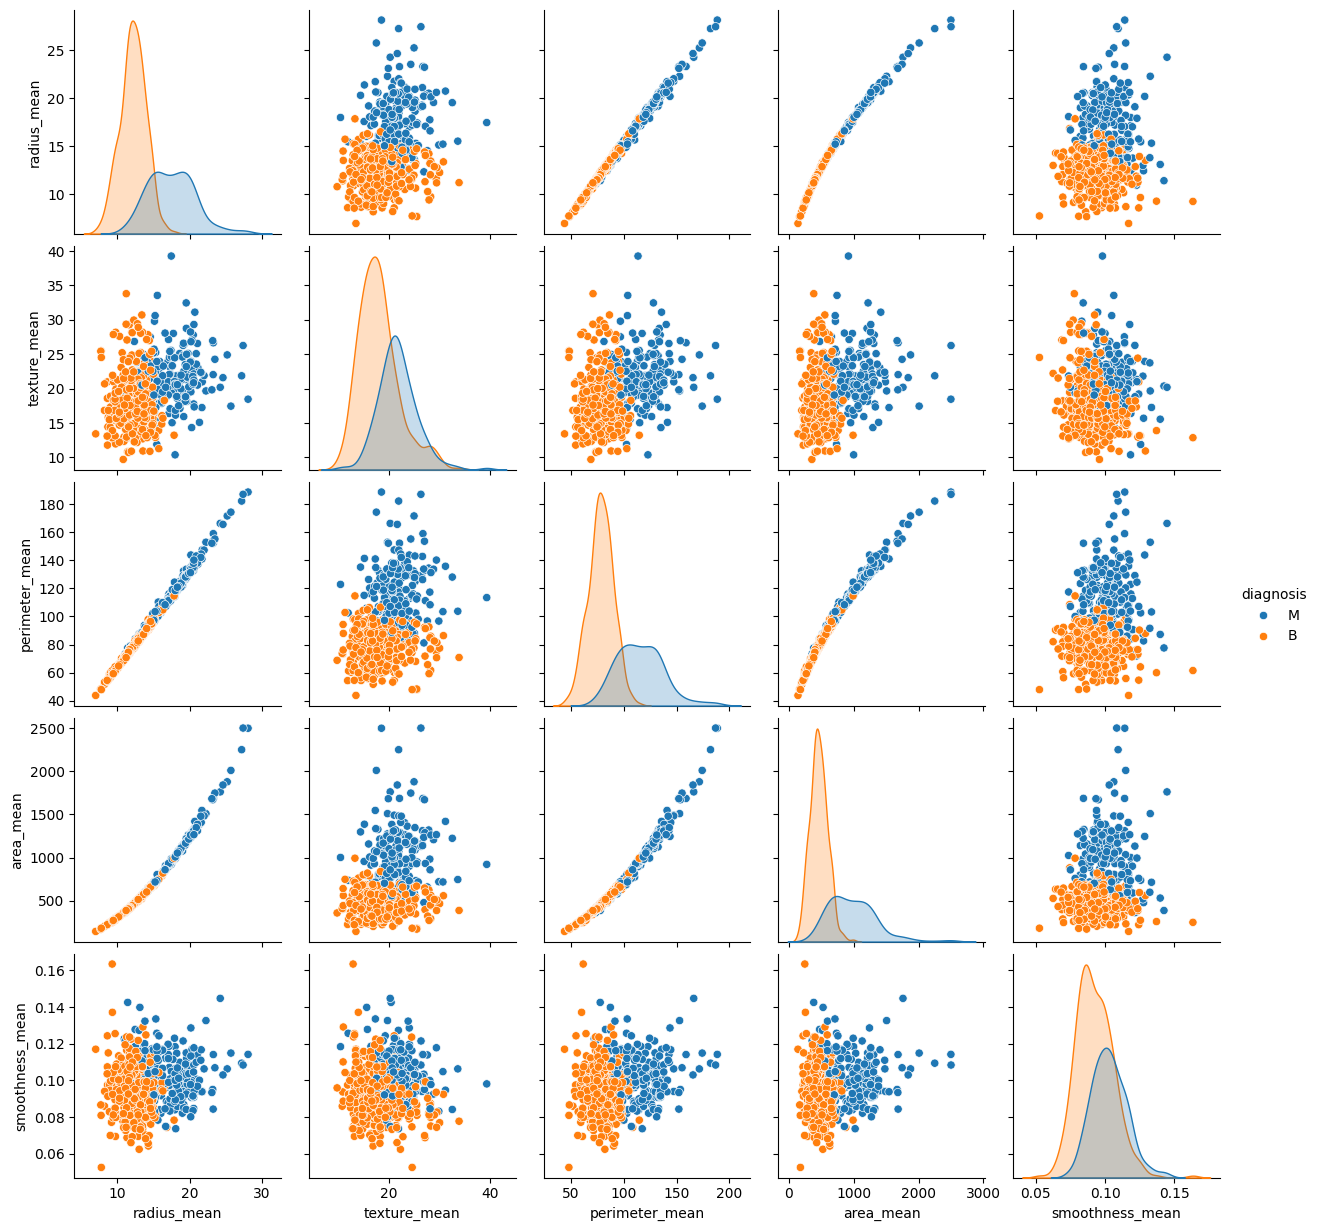

In [22]:
# Create a pairplot for the first few features
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df[["radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean", "diagnosis"]], 
             hue="diagnosis")
plt.show()

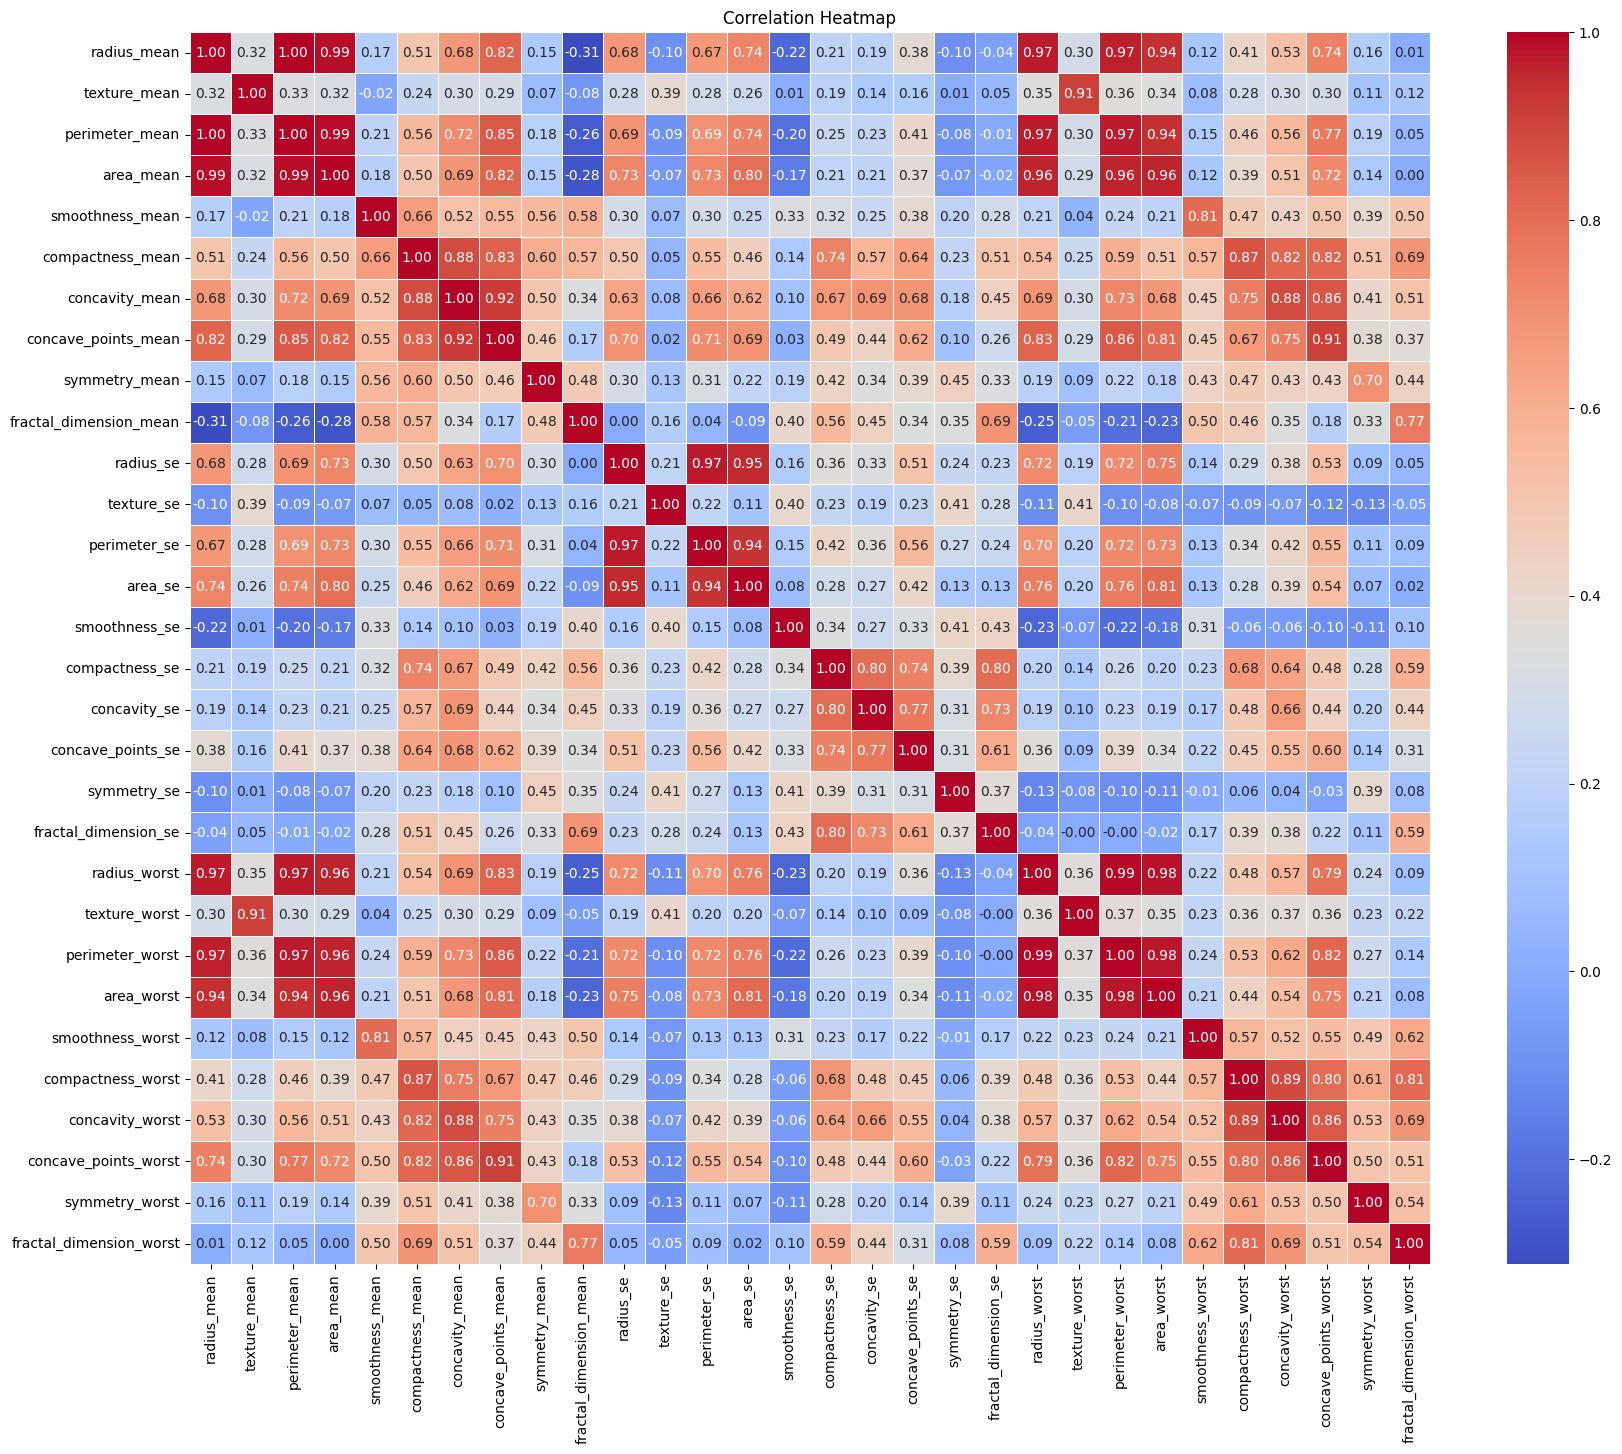

In [23]:
# Create a correlation coefficeint heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 16))
sns.heatmap(X.corr(), 
            annot=True,       # show correlation values in each cell
            fmt=".2f",        # round to 2 decimal places
            cmap="coolwarm",  # red = positive, blue = negative correlation
            linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

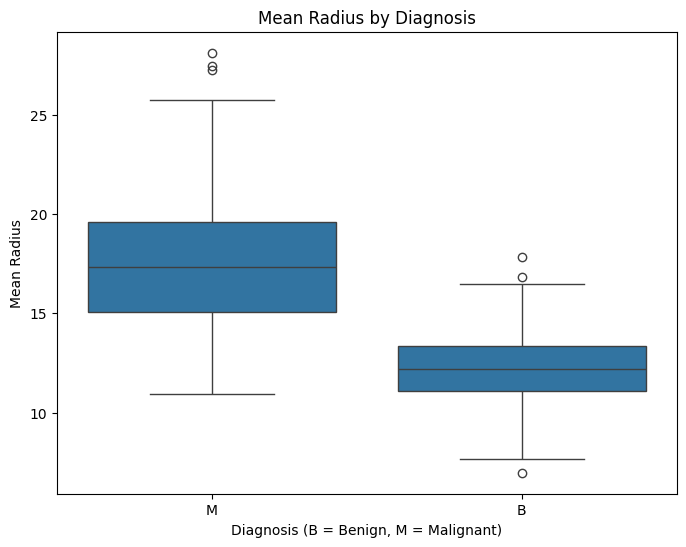

In [24]:
# Create a boxplot for mean radius by target type
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(x="diagnosis", y="radius_mean", data=df)
plt.title("Mean Radius by Diagnosis")
plt.xlabel("Diagnosis (B = Benign, M = Malignant)")
plt.ylabel("Mean Radius")
plt.show()

In [28]:
# Split data into training and test sets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y, test_size=0.25, random_state=42, shuffle=True, stratify=y #even out benign v/s malignant counts
)

In [30]:
# Build and train logistic regression model
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42, max_iter=10000, class_weight="balanced")
lr.fit(X_train, y_train)

Training accuracy: 98.36%
Test accuracy: 97.20%


In [31]:
# Evaluate the model
# check training accuracy
print(f'Training accuracy: {lr.score(X_train, y_train):.2%}')
print(f'Test accuracy: {lr.score(X_test, y_test):.2%}')

Training accuracy: 98.36%
Test accuracy: 97.20%


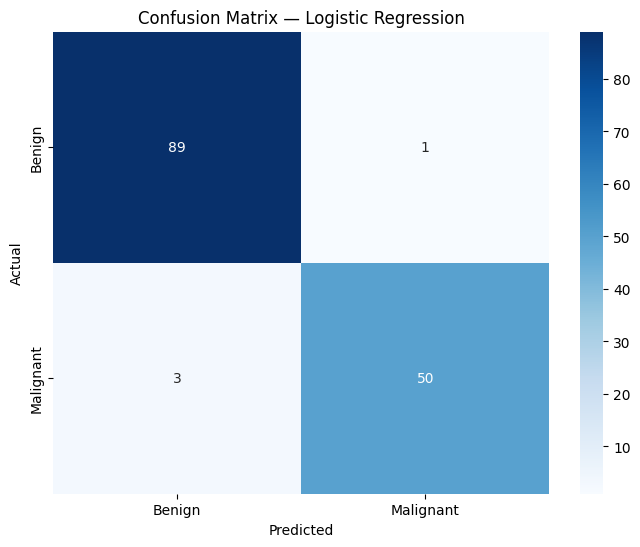

In [35]:
# Generate a confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = lr.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, 
            annot=True,           # show numbers in cells
            fmt="d",              # format as integers
            cmap="Blues",         # color scheme
            xticklabels=["Benign", "Malignant"],
            yticklabels=["Benign", "Malignant"])
plt.title("Confusion Matrix — Logistic Regression")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [34]:
# Generate a classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           B       0.97      0.99      0.98        90
           M       0.98      0.94      0.96        53

    accuracy                           0.97       143
   macro avg       0.97      0.97      0.97       143
weighted avg       0.97      0.97      0.97       143



In [36]:
# Extract coefficients
# Create a dataframe of feature names and their coefficients
coefficients = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lr.coef_[0]
})

# Sort by absolute value to see most influential features first
coefficients = coefficients.reindex(
    coefficients['coefficient'].abs().sort_values(ascending=False).index
)

print(coefficients)

                    feature  coefficient
21            texture_worst     1.410248
10                radius_se     1.323465
28           symmetry_worst     1.057481
15           compactness_se    -0.990094
7       concave_points_mean     0.971068
13                  area_se     0.911657
26          concavity_worst     0.888519
23               area_worst     0.888287
6            concavity_mean     0.877737
20             radius_worst     0.867916
12             perimeter_se     0.819394
27     concave_points_worst     0.757579
22          perimeter_worst     0.708448
19     fractal_dimension_se    -0.607132
5          compactness_mean    -0.579636
1              texture_mean     0.526600
17        concave_points_se     0.492085
11               texture_se    -0.400465
4           smoothness_mean     0.390930
24         smoothness_worst     0.372272
3                 area_mean     0.370415
18              symmetry_se    -0.337427
8             symmetry_mean    -0.300800
2            per

In [37]:
# Normalize the coefficients by the standard deviation
# Get standard deviations from the original data
std_devs = X.std()

# Normalize coefficients by standard deviation
coefficients = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lr.coef_[0],
    'std': std_devs.values,
    'normalized_coefficient': lr.coef_[0] * std_devs.values
})

# Sort by absolute normalized coefficient
coefficients = coefficients.reindex(
    coefficients['normalized_coefficient'].abs().sort_values(ascending=False).index
)

print(coefficients[['feature', 'coefficient', 'normalized_coefficient']])

                    feature  coefficient  normalized_coefficient
23               area_worst     0.888287              505.752271
3                 area_mean     0.370415              130.354424
13                  area_se     0.911657               41.472191
22          perimeter_worst     0.708448               23.805665
21            texture_worst     1.410248                8.667746
2            perimeter_mean     0.249481                6.062129
20             radius_worst     0.867916                4.194846
1              texture_mean     0.526600                2.264926
12             perimeter_se     0.819394                1.656696
0               radius_mean     0.244140                0.860360
10                radius_se     1.323465                0.367014
11               texture_se    -0.400465               -0.220916
26          concavity_worst     0.888519                0.185367
6            concavity_mean     0.877737                0.069973
28           symmetry_wor

In [38]:
# Sort feature names and coefficients by absolute value of coefficients
coefficients = coefficients.sort_values(
    by='normalized_coefficient', 
    key=abs, 
    ascending=False
)

print(coefficients[['feature', 'normalized_coefficient']])

                    feature  normalized_coefficient
23               area_worst              505.752271
3                 area_mean              130.354424
13                  area_se               41.472191
22          perimeter_worst               23.805665
21            texture_worst                8.667746
2            perimeter_mean                6.062129
20             radius_worst                4.194846
1              texture_mean                2.264926
12             perimeter_se                1.656696
0               radius_mean                0.860360
10                radius_se                0.367014
11               texture_se               -0.220916
26          concavity_worst                0.185367
6            concavity_mean                0.069973
28           symmetry_worst                0.065424
27     concave_points_worst                0.049797
7       concave_points_mean                0.037680
25        compactness_worst               -0.035974
5          c

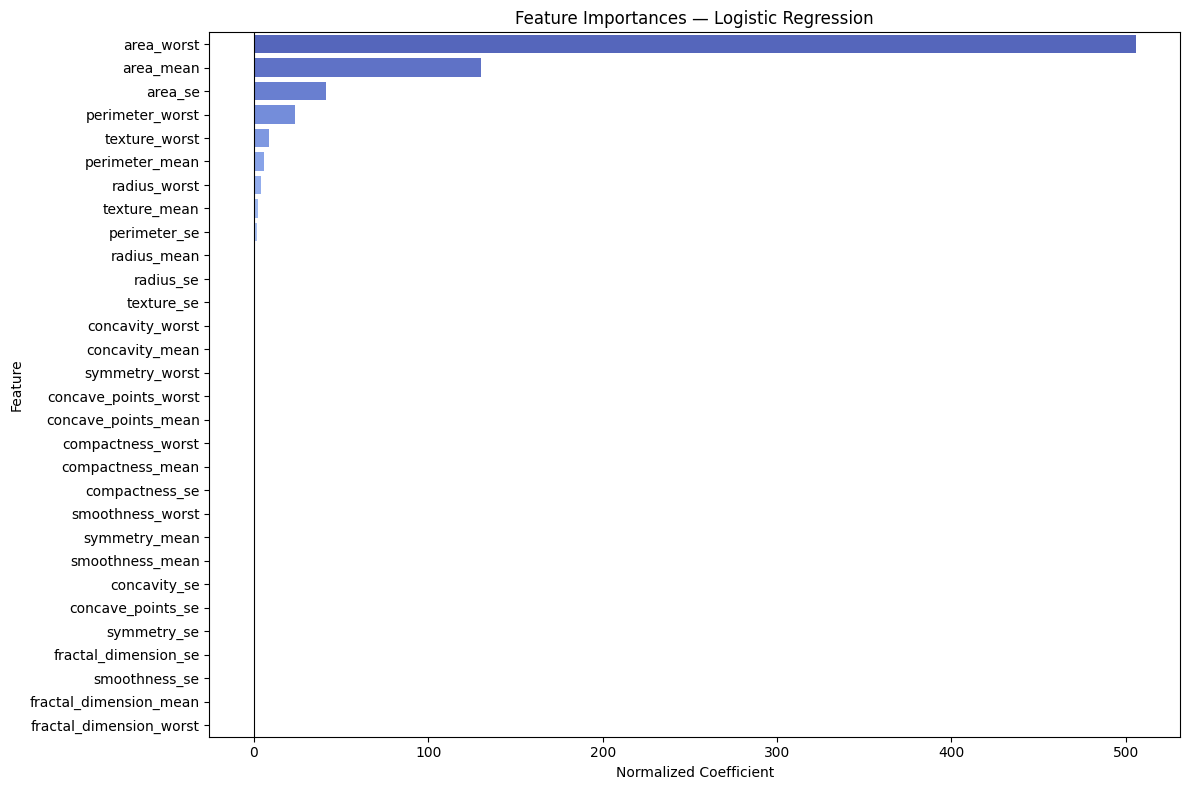

In [41]:
# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(
    x='normalized_coefficient', 
    y='feature', 
    data=coefficients,
    hue='feature',      
    legend=False,          
    palette='coolwarm',
    orient='h'
)
plt.title('Feature Importances — Logistic Regression')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('Normalized Coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()